# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

----
Автор: Федорова Марина Вячеславовна  
Дата: 05.03.2026

---
<a class="ancor" id="1-bullet"></a>
## Введение

<a class="ancor" id="2-bullet"></a>
### Цели и задачи проекта:

Используем датасеты, содержащие информацию о пользователях развлекательного приложения и об их активности в приложении. Рассчитаем параметры A/B-теста, который позволит проверить гипотезу о том, что новый алгоритм рекомендаций будет показывать более интересный контент для каждого пользователя. Оценим корректность его проведения и проанализируем результаты эксперимента.

---
<a class="ancor" id="26-bullet"></a>
<a class="ancor" id="3-bullet"></a>
### Содержание:

[Введение.](#1-bullet)
  * [Цели и задачи проекта.](#2-bullet)
  * [Содержание.](#3-bullet)
  * [Описание данных.](#4-bullet)
    
[1. Работа с историческими данными.](#5-bullet)
  * [1.1. Загрузка исторических данных.](#6-bullet)
  * [1.2. Знакомство с данными.](#7-bullet)
  * [1.3. Анализ числа регистраций.](#8-bullet)
  * [1.4. Анализ числа просмотренных страниц.](#9-bullet)
  * [1.5. Доля пользователей, посмотревших более четырёх страниц.](#10-bullet)
    
[2. Подготовка к тесту.](#11-bullet)    
  * [2.1. Расчёт размера выборки.](#12-bullet)
  * [2.2. Расчёт длительности А/В-теста.](#13-bullet)
    
[3. Мониторинг А/В-теста.](#14-bullet)    
  * [3.1. Проверка распределения пользователей.](#15-bullet)
  * [3.2. Проверка пересечений пользователей.](#16-bullet)
  * [3.3. Равномерность разделения пользователей по устройствам.](#17-bullet)
  * [3.4. Равномерность распределения пользователей по регионам.](#18-bullet)
  * [3.5. Вывод после проверки А/В-теста.](#19-bullet)
    
[4. Проверка результатов А/В-теста.](#20-bullet)
  * [4.1. Получение результатов теста и подсчёт основной метрики.](#21-bullet)
  * [4.2. Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик.](#22-bullet)
  * [4.3. Сравнение доли успешных сессий.](#23-bullet)
  * [4.4. Насколько статистически значимо изменение ключевой метрики.](#24-bullet)
  * [4.5. Вывод по результатам A/B-эксперимента.](#25-bullet)

<a class="ancor" id="4-bullet"></a>
## Описание данных

Будем работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).



[Назад к содержанию](#26-bullet)

---
<a class="ancor" id="5-bullet"></a>
### 1. Работа с историческими данными (EDA)

<a class="ancor" id="6-bullet"></a>
#### 1.1. Загрузка исторических данных
На первом этапе поработаем с историческими данными приложения:

Загрузим необходимые для работы библиотеки

In [1]:
# Импортируем библиотеку pandas
import pandas as pd

# Импортируем библиотеку numpy
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from statsmodels.stats.power import NormalIndPower, TTestIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

from math import ceil

Загрузим и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`. 

In [2]:
# Загружаем данные из датасета 'sessions_project_history.csv'
sessions_history = pd.read_csv("https://code.s3.yandex.net/datasets/sessions_project_history.csv")

In [3]:
# Выводим на экран первые строки датафрейма 'sessions_history'
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


[Назад к содержанию](#26-bullet)

<a class="ancor" id="7-bullet"></a>
#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. 

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
# Рассчитаем количество сессий для каждого пользователя
sessions_counts = sessions_history['user_id'].value_counts()

In [5]:
# Находим пользователя с наибольшим количеством сессий
top_user = sessions_counts.index[0]

# Выводим данные из таблицы для одного пользователя
sessions_history[sessions_history['user_id'] == top_user]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


Судя по выгруженной таблице для одного пользователя с наибольшим количеством сессий, пользователь с id `10E0DEFC1ABDBBE0` посещал приложения почти каждый день с 14 августа по 25 августа, пропустив 21 и 23 августа. В остальные даты посещений не наблюдалось. Также можно заметить, что количество просмотренных страниц во время сессий в среднем составляет две страницы. В столбце `registration_flag` для данного пользователя указан признак `0`, что говорит о том, что пользователь не зарегистрирован. Регион пользователя принадлежит `CIS` - страны СНГ.

[Назад к содержанию](#26-bullet)

<a class="ancor" id="8-bullet"></a>
#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты будем считать, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразим их на одном графике.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.


In [6]:
# Преобразуем тип данных в столбце 'session_date'
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

In [7]:
# Считаем количество сессий на пользователя
user_session_cnt = sessions_history.groupby('user_id')['session_id'].count()

# Найдём количество уникальных пользователей
count_unique = sessions_history.groupby('session_date')['user_id'].nunique()

# Найдём количество зарегистрированных пользователей для каждого дня
count_registered = sessions_history.groupby('session_date')['registration_flag'].sum()

# Объединим результаты в один датафрейм
users_cnt = pd.DataFrame({
    'unique_users': count_unique,
    'registered_users': count_registered
}).reset_index()

# Переименовываем столбец с датой для ясности
users_cnt.rename(columns={'session_date': 'session_day'}, inplace=True)
    
users_cnt['unique_users'] = users_cnt['unique_users'].astype(int)
users_cnt['registered_users'] = users_cnt['registered_users'].astype(int)
users_cnt['session_day'] = pd.to_datetime(users_cnt['session_day']).dt.strftime('%m-%d')

# Выводим датафрейм для наглядности
users_cnt.T

,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
session_day,08-11,08-12,08-13,08-14,08-15,08-16,08-17,08-18,08-19,08-20,...,09-14,09-15,09-16,09-17,09-18,09-19,09-20,09-21,09-22,09-23
unique_users,3919,6056,8489,10321,14065,12205,11200,10839,12118,13514,...,4364,3698,3032,2548,1952,1418,1100,776,546,317
registered_users,169,336,464,625,840,916,833,860,831,1008,...,440,383,286,272,201,132,107,87,68,32


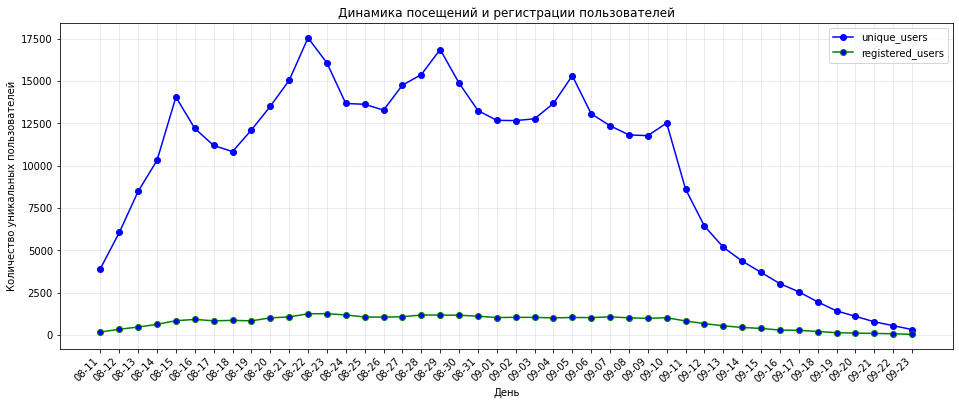

In [8]:
# Создаём контейнер графика matplotlib и задаём размер
fig, ax = plt.subplots(figsize=(16, 6))

# Строим линейный график
users_cnt.plot(
               kind='line',
               ax=ax,
               legend=True,
               color=['blue', 'green'],
               marker='o',
               markerfacecolor='b',
               title='Динамика посещений и регистрации пользователей')

# Настраиваем оформление графика
ax.set_xlabel('День')
ax.set_ylabel('Количество уникальных пользователей')

# Добавляем сетку графика (для осей ax)
ax.grid(True, alpha=0.3)  # alpha — прозрачность сетки

# Устанавливаем деления с шагом 1 (каждый день/единица)
plt.xticks(np.arange(0, len(users_cnt), 1))

# Улучшаем отображение дат на оси X
ax.set_xticklabels(users_cnt['session_day'], rotation=45, ha='right')

# Выводим график
plt.show()

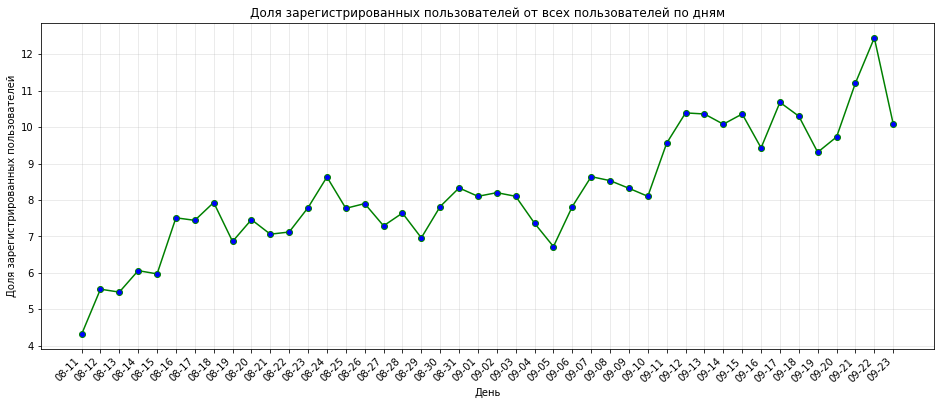

In [9]:
# Определим долю зарегистрированных пользователей
perc_registered = round(users_cnt['registered_users'] / users_cnt['unique_users'] * 100, 2)

# Создаём контейнер графика matplotlib и задаём размер
fig, ax = plt.subplots(figsize=(16, 6))

# Строим линейный график
perc_registered.plot(
               kind='line',
               ax=ax,
               x='session_day',
               color='green',
               marker='o',
               markerfacecolor='b',
               title='Доля зарегистрированных пользователей от всех пользователей по дням')

# Настраиваем оформление графика
ax.set_xlabel('День')
ax.set_ylabel('Доля зарегистрированных пользователей')

# Добавляем сетку графика (для осей ax)
ax.grid(True, alpha=0.3)  # alpha — прозрачность сетки

# Устанавливаем деления с шагом 1 (каждый день/единица)
plt.xticks(np.arange(0, len(users_cnt), 1))

# Улучшаем отображение дат на оси X
ax.set_xticklabels(users_cnt['session_day'], rotation=45, ha='right')

# Выводим график
plt.show()

На графике `Динамика посещений и регистрации пользователей` можем увидеть, что в начале исторических данных идёт увеличение числа посещений пользователями, а в конце периода (с 11 сентября) - спад посещений. В середине наблюдаемого периода `динамика посещений` носит волнообразный характер. Пики активности наблюдаются практически каждые 7 дней и приходятся на пятницу (15 августа 2025г. - пятница). В выходные, в основном, идёт спад, к середине недели - снова рост. 

В динамика `регистрации` линия более плавная, без резких пиков и значительно меньше посещаемости, что вполне логично, т.к. не всякая посещаемость переходит в регистрацию.

График `Доля зарегистрированных пользователей от всех пользователей` показывает постепенный рост доли зарегистрированных пользователей с незначительными подъёмами и спадами на протяжении всего наблюдаемого периода. 

[Назад к содержанию](#26-bullet)

<a class="ancor" id="9-bullet"></a>
#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируем число просмотренных страниц во время первых сессий пользователей. Найдём количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.


In [10]:
# Фильтруем по номеру сессий
first_session = sessions_history[sessions_history['session_number'] == 1]

# Найдем количество первых сессий для каждого количества просмотренных страниц
cnt_sessions = first_session.groupby('page_counter')['session_id'].count().reset_index()

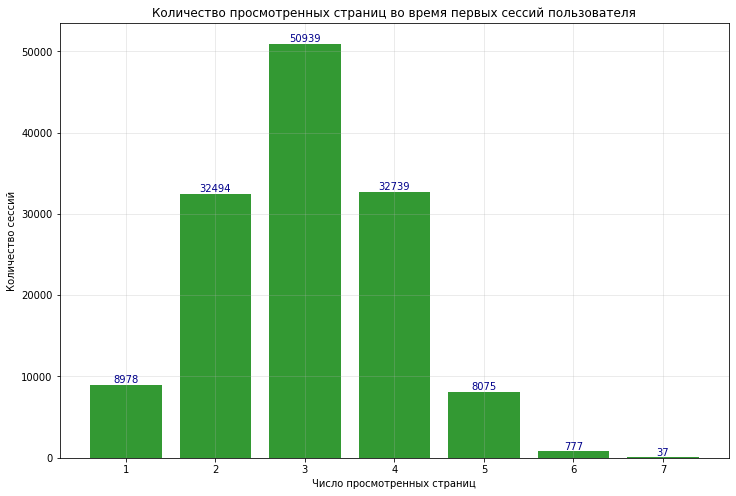

In [11]:
# Создаём контейнер графика matplotlib и задаём размер
fig, ax = plt.subplots(figsize=(12, 8))

# Строим столбчатую диаграмму и сохраняем объекты столбцов
bars = ax.bar(
    x=cnt_sessions['page_counter'],
    height=cnt_sessions['session_id'],
    color='green',
    alpha=0.8
)

# Добавляем подписи значений на каждый столбец
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # позиция X: центр столбца
        height + 1,                             # позиция Y: чуть выше вершины столбца
        f'{int(height)}',                     # текст: значение (целое число)
        ha='center',                         # выравнивание по горизонтали
        va='bottom',                        # выравнивание по вертикали
        fontsize=10,
        color='darkblue'
    )

# Настраиваем оформление графика
ax.set_title('Количество просмотренных страниц во время первых сессий пользователя')
ax.set_xlabel('Число просмотренных страниц')
ax.set_ylabel('Количество сессий')

# Добавляем сетку графика (для осей ax)
ax.grid(True, alpha=0.3)  # alpha — прозрачность сетки

# Выводим график
plt.show()

Исходя из данных простроенного графика, можно сделать вывод, что во время первых сессий пользователи в большем случае (`50939 сессий`) просматривали `3 страницы`. По `2` и `4 страницы` просматривали меньшее количество пользователей: `32494` и `32739` сессий соответственно. Аутсайдером в этом списке оказались `7 страниц` - количество сессий во время первого посещения оказалось всего `37`.

[Назад к содержанию](#26-bullet)

<a class="ancor" id="10-bullet"></a>
#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [12]:
# Используем функцию 
def group_sessions(row):
    if row['page_counter'] >= 4:
        return 1
    else: 
        return 0

In [13]:
# Создадим новый столбец 'good_session'
sessions_history['good_session'] = sessions_history.apply(group_sessions, axis=1)
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone,0
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android,1
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC,1
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android,1
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android,0


In [14]:
# Найдём количество сессий
session_count = sessions_history.groupby('session_date')['good_session'].count()

# Фильтруем по успешности сессии
filtered_session = sessions_history[sessions_history['good_session'] == 1]

# Найдём количество успешных сессий
successful_session = filtered_session.groupby('session_date')['good_session'].sum()

# Рассчитаем среднее значение доли успешных сессий по дням
perc_session = successful_session / session_count
mean_perc_session = perc_session.groupby('session_date').mean().reset_index()

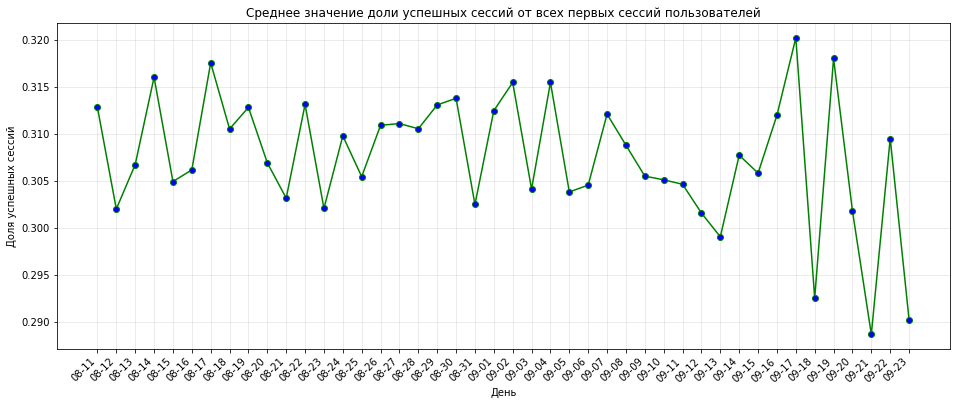

In [15]:
mean_perc_session['session_date'] = pd.to_datetime(mean_perc_session['session_date']).dt.strftime('%m-%d')

# Создаём контейнер графика matplotlib и задаём размер
fig, ax = plt.subplots(figsize=(16, 6))

# Строим линейный график
mean_perc_session.plot(
               kind='line',
               ax=ax,
               x='session_date',
               color='green',
               marker='o',
               markerfacecolor='b',
               legend=False,
               title='Среднее значение доли успешных сессий от всех первых сессий пользователей')

# Настраиваем оформление графика
ax.set_xlabel('День')
ax.set_ylabel('Доля успешных сессий')

# Добавляем сетку графика (для осей ax)
ax.grid(True, alpha=0.3)  # alpha — прозрачность сетки

# Устанавливаем деления с шагом 1 (каждый день/единица)
plt.xticks(np.arange(0, len(mean_perc_session), 1))

# Улучшаем отображение дат на оси X
ax.set_xticklabels(mean_perc_session['session_date'], rotation=45, ha='right')

# Выводим график
plt.show()

Различие среднего значения доли успешных сессий от всех первых сессий пользователей по дням в основном незначительно и колеблется от `30` до `31,5%`, демонстрируя волнообразную динамику. Однако в конце наблюдаемого периода, `с 16 по 23 сентября`, можно заметить резкие колебания `приблизительно 2.5-3%`. 

[Назад к содержанию](#26-bullet)

---
<a class="ancor" id="11-bullet"></a>
### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определимся с целевой метрикой.

- Рассчитаем необходимый размер выборки.

- Исходя из текущих значений трафика рассчитаем необходимую длительность проведения теста.

<a class="ancor" id="12-bullet"></a>
#### 2.1. Расчёт размера выборки
Рассчитаем необходимое для эксперимента количество пользователей.

Для этого установим в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используем метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.


In [16]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1-beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.009  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


[Назад к содержанию](#26-bullet)

<a class="ancor" id="13-bullet"></a>
#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста, исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [17]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = users_cnt['unique_users'].mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


После установки необходимых параметров рассчитали необходимый размер `выборки`, который составил `41040` пользователей для каждой группы эксперимента. 
Для среднего дневного трафика приложения в `~9908 пользователей` определили длительность теста в количестве `9 дней`. 

[Назад к содержанию](#26-bullet)

---
<a class="ancor" id="14-bullet"></a>
### 3. Мониторинг А/В-теста

<a class="ancor" id="15-bullet"></a>
#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.

- Считаем и сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. Построим удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [18]:
# Загружаем данные из датасета 'sessions_project_test.csv'
sessions_test_part = pd.read_csv("https://code.s3.yandex.net/datasets/sessions_project_test_part.csv")

In [19]:
# Выводим первые строки датафрейма
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [20]:
# Агрегируем по тестовым группам и дате уникальных пользователей
df_grp = (sessions_test_part.groupby(['test_group', 'session_date']).agg({'user_id': 'nunique',}).reset_index())
x = df_grp['session_date'].unique()

# Группа A
y_a = df_grp[df_grp['test_group'] == 'A']['user_id']
# Группа B
y_b = df_grp[df_grp['test_group'] == 'B']['user_id']

# Создадим сводную таблицу для дальнейшей работы
pivot_table = df_grp.pivot(index='session_date', columns='test_group', values='user_id').reset_index()
pivot_table

test_group,session_date,A,B
0,2025-10-14,1477,1466


In [21]:
# Рассчитаем процентную разницу в количестве пользователей в группах A и B
result = 100 * (pivot_table['A'] - pivot_table['B']) / pivot_table['A']

# Выводим процунтную разницу
display("Процентное отклонение группы B от группы A по дням:")
for date, value in result.items():
    display(f"{value:.2f}%")

'Процентное отклонение группы B от группы A по дням:'

'0.74%'

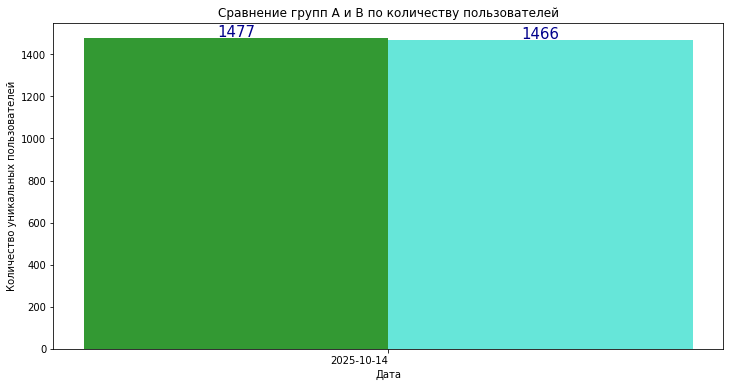

In [22]:
# Создаём контейнер графика matplotlib и задаём размер
fig, ax = plt.subplots(figsize=(12, 6))

# Позиции для столбцов группы A
x_a = [i - 0.2 for i in range(len(pivot_table))]
# Позиции для столбцов группы B
x_b = [i + 0.2 for i in range(len(pivot_table))]

# Строим столбчатую диаграмму для группы A
bars_a = ax.bar(
    x=x_a,
    height=pivot_table['A'],
    color='green',
    alpha=0.8,
    linewidth=1,
    width=0.4
)

# Строим столбчатую диаграмму для группы B
bars_b = ax.bar(
    x=x_b,
    height=pivot_table['B'],
    color='turquoise',
    alpha=0.8,
    linewidth=1,
    width=0.4
)

# Добавляем подписи значений на каждый столбец
for bars, height in [(bars_a, pivot_table['A']), (bars_b, pivot_table['B'])]:
    for bar, h in zip(bars, height):
        ax.text(
        bar.get_x() + bar.get_width() / 2,  # позиция X: центр столбца
        height - 5,                         # позиция Y: чуть выше вершины столбца
        f'{int(height)}',                   # текст: значение (целое число)
        ha='center',                        # выравнивание по горизонтали
        va='bottom',                        # выравнивание по вертикали
        fontsize=15,
        color='darkblue'
    )

# Настраиваем оформление графика
ax.set_title('Сравнение групп A и B по количеству пользователей')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество уникальных пользователей')

# Добавляем FixedLocator
ax.xaxis.set_major_locator(ticker.FixedLocator(range(len(pivot_table))))

# Улучшаем отображение дат на оси X
ax.set_xticklabels(pivot_table['session_date'], rotation=0, ha='right')

# Выводим график
plt.show()

Процент отклонения `группы В` от `группы А` на `2025-10-14` составил `~0.74`, в абсолютном значении - `11` пользователей.  Полученные значения показывают, что в группе с действующим алгоритмом пользователи количество пользователей немного больше, чем в группе с новым алгоритмом. Эффект мал и на текущем этапе рано говорить о статистической значимости, это лишь предварительное наблюдение. 

[Назад к содержанию](#26-bullet)

<a class="ancor" id="16-bullet"></a>
#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [23]:
# Проверка пересечения пользователей между группами
old = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
new = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']
intersection = list(set(new) & set(old))
display("Пользователи в обеих группах:", intersection)

'Пользователи в обеих группах:'

[]

Группы независимы. Пользователи в обеих группах разные.

[Назад к содержанию](#26-bullet)

<a class="ancor" id="17-bullet"></a>
#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Добавим на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [24]:
# Определим доступные типы устройств
sessions_test_part['device'].unique()

array(['Android', 'iPhone', 'PC', 'Mac'], dtype=object)

In [25]:
# Подсчитаем доли каждого типа устройств для группы А
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']

unique_users_per_device = group_A.groupby('device')['user_id'].nunique()
share_device_A = ((unique_users_per_device / unique_users_per_device.sum() * 100).round(2)).reset_index()

display("Доля каждого типа устройства для пользователей из группы A:")
share_device_A.T

'Доля каждого типа устройства для пользователей из группы A:'

,0,1,2,3
device,Android,Mac,PC,iPhone
user_id,44.41,10.56,24.98,20.04


In [26]:
# Подсчитаем доли каждого типа устройств для группы B
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']

unique_users_per_device = group_B.groupby('device')['user_id'].nunique()
share_device_B = ((unique_users_per_device / unique_users_per_device.sum() * 100).round(2)).reset_index()

display("Доля каждого типа устройства для пользователей из группы B:")
share_device_B.T

'Доля каждого типа устройства для пользователей из группы B:'

,0,1,2,3
device,Android,Mac,PC,iPhone
user_id,45.57,10.1,25.99,18.35


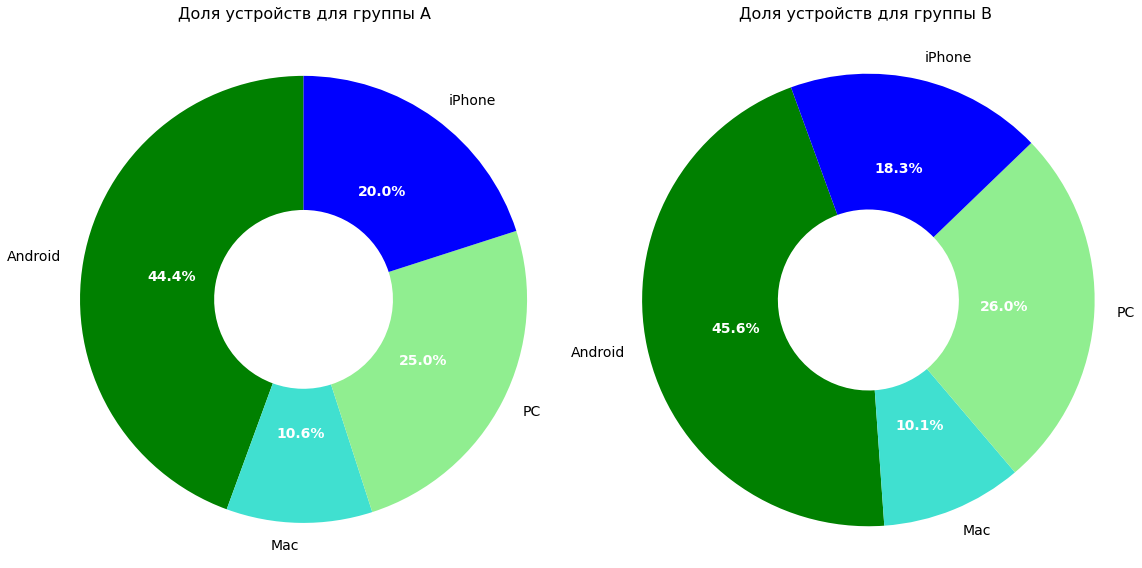

In [27]:
# Создаём фигуру с двумя подграфиками 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))


# Извлекаем метки и значения для диаграммы группы А
labels_A = share_device_A['device'].tolist()  # названия устройств
values_A = share_device_A['user_id'].tolist()   # доли 

# Извлекаем метки и значения для диаграммы группы В
labels_B = share_device_B['device'].tolist()  # названия устройств
values_B = share_device_B['user_id'].tolist()   # доли

# Установим цвета для диаграмм
colors = ['green', 'turquoise', 'lightgreen', 'blue']

# Построим кольцевую диаграмму для группы А
wedges1, texts1, autotexts1 = ax1.pie(
    values_A,
    labels=labels_A,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6),
    textprops={'fontsize': 14}
)
ax1.set_title('Доля устройств для группы A', fontsize=16, pad=20)
plt.setp(autotexts1, size=14, weight='bold', color='white')

# Построим кольцевую диаграмму для группы B 
wedges2, texts2, autotexts2 = ax2.pie(
    values_B,
    labels=labels_B,
    colors=colors,
    autopct='%1.1f%%',
    startangle=110,
    wedgeprops=dict(width=0.6),
    textprops={'fontsize': 14}
)
ax2.set_title('Доля устройств для группы B', fontsize=16, pad=20)
plt.setp(autotexts2, size=14, weight='bold', color='white')

# Гарантируем, что обе диаграммы круглые
ax1.axis('equal')
ax2.axis('equal')

# Выводим график
plt.tight_layout()
plt.show()

По полученным результам и построенным диаграммам можно сделать вывод, что распределение по группам A и B по типу устройств произошло равномерно. Максимальная разница по типу устройств не существенна и составляет `1.7%`.

[Назад к содержанию](#26-bullet)

<a class="ancor" id="18-bullet"></a>
#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Добавим на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Используем другой тип диаграммы, не тот, что в прошлом задании.

In [28]:
# Определим регионы в датафрейме
sessions_test_part['region'].unique()

array(['CIS', 'MENA', 'EU'], dtype=object)

In [29]:
# Подсчитаем доли каждого региона для группы А
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']

unique_users_per_device = group_A.groupby('region')['user_id'].nunique()
share_region_A = ((unique_users_per_device / unique_users_per_device.sum() * 100).round(2)).reset_index()

display("Доля каждого региона для пользователей из группы A:")
share_region_A.T

'Доля каждого региона для пользователей из группы A:'

,0,1,2
region,CIS,EU,MENA
user_id,43.6,15.17,41.23


In [30]:
# Подсчитаем доли каждого региона для группы А
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']

unique_users_per_device = group_B.groupby('region')['user_id'].nunique()
share_region_B = ((unique_users_per_device / unique_users_per_device.sum() * 100).round(2)).reset_index()

display("Доля каждого региона для пользователей из группы B:")
share_region_B.T

'Доля каждого региона для пользователей из группы B:'

,0,1,2
region,CIS,EU,MENA
user_id,44.0,14.8,41.2


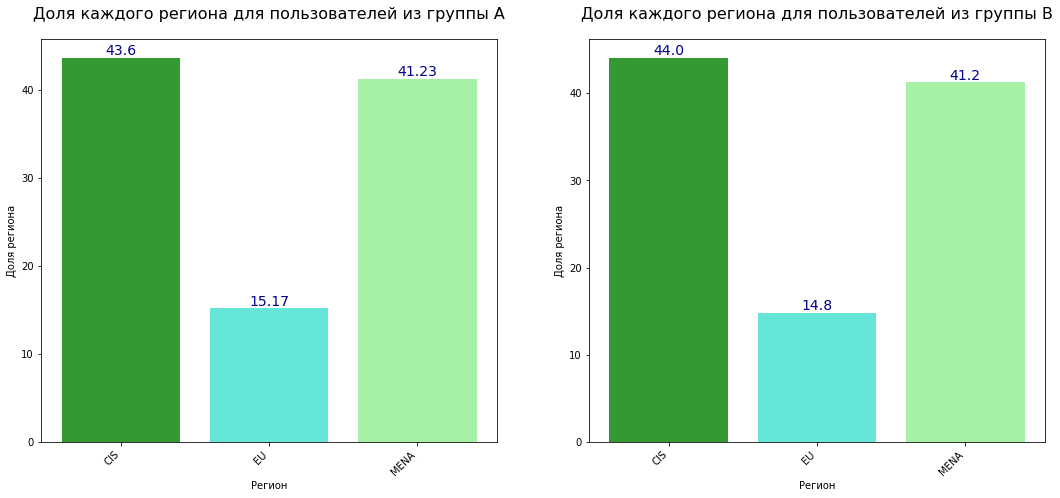

In [31]:
# Создаём фигуру с двумя подграфиками 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))


# Извлекаем метки и значения для диаграммы группы А
region_A = share_region_A['region'].tolist()  # названия устройств
share_A = share_region_A['user_id'].tolist()   # доли 

# Извлекаем метки и значения для диаграммы группы В
region_B = share_region_B['region'].tolist()  # названия устройств
share_B = share_region_B['user_id'].tolist()   # доли

# Установим цвета для диаграмм
colors = ['green', 'turquoise', 'lightgreen']

# Построим столбчатую диаграмму для группы A
bars_A = ax1.bar(
    x=region_A,
    height=share_A,
    color=colors,
    alpha=0.8
)
ax1.set_title('Доля каждого региона для пользователей из группы A', fontsize=16, pad=20)
ax1.set_xlabel('Регион')
ax1.set_ylabel('Доля региона')

# Добавляем подписи значений на каждый столбец
for bar in bars_A:
       height = bar.get_height()
       ax1.text(
           bar.get_x() + bar.get_width() / 2,
           height + 0.002,
           f'{height}',
           ha='center',
           va='bottom',
           fontsize=14,
           color='darkblue'
       )
# Добавляем FixedLocator
ax1.xaxis.set_major_locator(ticker.FixedLocator(range(len(share_region_A))))
    
# Улучшаем отображение дат на оси X
ax1.set_xticklabels(region_A, rotation=45, ha='right')

# Построим столбчатую диаграмму для группы B
bars_B = ax2.bar(
    x=region_B,
    height=share_B,
    color=colors,
    alpha=0.8
)
ax2.set_title('Доля каждого региона для пользователей из группы B', fontsize=16, pad=20)
ax2.set_xlabel('Регион')
ax2.set_ylabel('Доля региона')

# Добавляем подписи значений на каждый столбец
for bar in bars_B:
       height = bar.get_height()
       ax2.text(
           bar.get_x() + bar.get_width() / 2,
           height + 0.002,
           f'{height}',
           ha='center',
           va='bottom',
           fontsize=14,
           color='darkblue'
       )
# Добавляем FixedLocator
ax2.xaxis.set_major_locator(ticker.FixedLocator(range(len(share_region_B))))
    
# Улучшаем отображение дат на оси X
ax2.set_xticklabels(region_B, rotation=45, ha='right')

# Настраиваем маржи
plt.subplots_adjust(bottom=0.15, top=0.85)

# Выводим график
plt.show()

Доли каждого региона для пользователей из групп А и В распределены равномерно. Максимальная разница по региону не существенна и составляет `0.4%`.

[Назад к содержанию](#26-bullet)

<a class="ancor" id="19-bullet"></a>
#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

-----
На основе проведённого анализа А/В-теста можно сделать следующие выводы:
* При сравнении количества пользователей в обеих группах обнаружили некоторые различия, а именно то, что группа А на 11 пользователей больше группы В, что сотавляет `0,74%`. Эффект мал и на текущем этапе рано говорить о статистической значимости, это лишь предварительное наблюдение.
* Пересечение пользователей из тестовой и контрольной групп обнаружено не было. `Выборки являются независимыми`. 
* Распределение пользователей тестовой и контрольной групп по категориальным переменным показали несущественные различия в группах как по типу устройств, так и по регионам. По типу устройств максимальная разница составляет 1.7%. Распределение пользователей по регионам более равномерное: максимальная разница составила 0.4%.

Перечисленные выводы дают основание сделать вывод, что, в целом, тест проходит корректно, критических нарушений не выявлено. Неравномерные распределения по категориальным переменным допустимы в пределах 3-5% - при большом объеме выборки перекосы нивелируются и не искажают результатов. Небольшое различие в размере групп также допустимо если разница сохраняется на протяжении теста. 

[Назад к содержанию](#26-bullet)

---
<a class="ancor" id="20-bullet"></a>
### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

<a class="ancor" id="21-bullet"></a>
#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считаем и сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [32]:
# Загружаем данные из датасета 'sessions_project_test.csv'
sessions_test = pd.read_csv("https://code.s3.yandex.net/datasets/sessions_project_test.csv")

In [33]:
# Выводим первые строки датафрейма
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [34]:
# Создадим новый столбец 'good_session'
sessions_test['good_session'] = sessions_test.apply(group_sessions, axis=1)

[Назад к содержанию](#26-bullet)

<a class="ancor" id="22-bullet"></a>
#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

---
Перед тем как проводить A/B-тест сформулируем нулевую и альтернативные гипотезы.

**Сформулируем гипотезу:** Внедрение нового алгоритма рекомендаций увеличит долю успешных сессий.

**Нулевая гипотеза:** *Изменение доли успешных сессий Группы В статистически не значимо доли успешных сессий Группы А.
$H_0$ = $H_1$*

**Альтернативная гипотеза:** *Изменение доли успешных сессий Группы В статистически значимо выше Группы А.
$H_0$ < $H_1$*

* В качестве `целевой метрики` возьмём долевую метрику, а именно `долю успешных сессий`.  Успешными сессиями будем считать сессии, в рамках которых пользователь просмотрел 4 и более страниц. 
* За `прокси-метрику` примем `количество просмотренных страниц`.
* `Барьерной метрикой` будем считать `среднее количество уникальных пользователей`.

[Назад к содержанию](#26-bullet)

<a class="ancor" id="23-bullet"></a>
#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразим на экране.

In [35]:
# Фильтруем датафрейм по тест_группам и первой сессии
sessions_test_A = sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)]
sessions_test_B = sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)]

# Найдём количество сессий для каждой из групп
session_count_A = sessions_test_A['good_session'].count()
session_count_B = sessions_test_B['good_session'].count()

# Фильтруем по успешности сессии для каждой из групп
f_session_A = sessions_test_A[sessions_test_A['good_session'] == 1]
f_session_B = sessions_test_B[sessions_test_B['good_session'] == 1]

# Найдём количество успешных сессий для каждой из групп
successful_session_A = f_session_A['good_session'].sum()
successful_session_B = f_session_B['good_session'].sum()

# Рассчитаем долю успешных сессий для каждой из групп
share_session_A = successful_session_A / session_count_A
share_session_B = successful_session_B / session_count_B

# Рассчитаем разницу успешных долей между группами
difference = round((share_session_B - share_session_A) * 100, 2)

# Выводим результаты
display(f'Доля успешных сессий для пользователей Группы А: {share_session_A}')

display(f'Доля успешных сессий для пользователей Группы B: {share_session_B}')

display(f'Доля успешных сессий в экспериментальной группе больше чем в контрольной на {difference} %')

'Доля успешных сессий для пользователей Группы А: 0.31572351932462733'

'Доля успешных сессий для пользователей Группы B: 0.3146730669434354'

'Доля успешных сессий в экспериментальной группе больше чем в контрольной на -0.11 %'

----
Проведём проверку динамики количества просмотренных страниц в группах A и B эксперимента на сопоставимость.

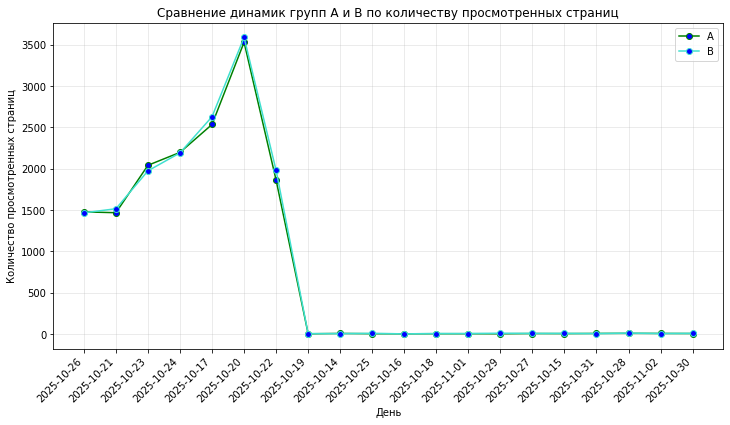

In [36]:
# Сравним прокси-метрики в течение всего эксперимента
# Найдём количество просмотренных страниц для каждой из групп
page_count_A = sessions_test_A.groupby('session_date')['page_counter'].count()
page_count_B = sessions_test_B.groupby('session_date')['page_counter'].count()
x = sessions_test['session_date'].unique()

# Создадим датафрейм для удобства визуализации
comparison_cnt_page = pd.DataFrame({
    'A':page_count_A,
    'B':page_count_B,
    'day': x
})

# Создаём контейнер графика matplotlib и задаём размер
fig, ax = plt.subplots(figsize=(12, 6))

# Строим линейный график
comparison_cnt_page.plot(
                    kind='line',
                    ax=ax,
                    legend=True,
                    color=['green', 'turquoise'],
                    marker='o',
                    markerfacecolor='b',
                    title='Сравнение динамик групп А и В по количеству просмотренных страниц')

# Настраиваем оформление графика
ax.set_xlabel('День')
ax.set_ylabel('Количество просмотренных страниц')

# Добавляем сетку графика (для осей ax)
ax.grid(True, alpha=0.3)  # alpha — прозрачность сетки

# Устанавливаем деления с шагом 1 (каждый день/единица)
plt.xticks(np.arange(0, len(comparison_cnt_page), 1))

# Улучшаем отображение дат на оси X
ax.set_xticklabels(comparison_cnt_page['day'], rotation=45, ha='right')

# Выводим график
plt.show()

Прокси_метрика демонстрирует одинаковую динамику, что говорит о сопоставимости количества просмотренных страниц.

Расчёт разницы показателей показал, что `доля успешных сессий` в тестовой группе меньше, чем в контрольной группе на `-0.11%`. Но на текущем этапе рано делать какие_либо выводы, необходимо провести статистический тест.

[Назад к содержанию](#26-bullet)

<a class="ancor" id="24-bullet"></a>
#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведем на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

Так как за целевую метрику мы взяли `долю` успешных сессий, то для анализа А/В-теста будем использовать `Z-тест пропорций`. Он оценивает разницу между долями успехов в двух группах и сравнивает её со стандартным нормальным распределением.

In [37]:
# Рассчитаем общее количество наблюдений для каждой из групп
total_number_A = sessions_test_A.shape[0]
total_number_B = sessions_test_B.shape[0]
display(f'Группа А: {total_number_A}') 
display(f'Группа B: {total_number_B}')

# Проверим выполняется ли предпосылка Z-теста пропорций о достаточном размере выборок
if (share_session_A * total_number_A > 10) and ((1 - share_session_A) * total_number_A > 10)and (share_session_B * total_number_B > 10) and ((1 - share_session_B) * total_number_B > 10):
    display('Предпосылка о достаточном количестве данных выполняется!')
else:
    display('Предпосылка о достаточном количестве данных НЕ выполняется!')

'Группа А: 15162'

'Группа B: 15416'

'Предпосылка о достаточном количестве данных выполняется!'

In [38]:
# Применим Z-тест пропорций для проверки гипотезы
stat_ztest, p_value_ztest = proportions_ztest(
    [successful_session_A, successful_session_B],
    [total_number_A, total_number_B],
    alternative='smaller' # так как H_1: p_a < p_b
)

# Сравниваем p-value с уровнем значимости
if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=0.5783523649187868 > 0.05
Нулевая гипотеза находит подтверждение!


Анализ А/В-тестирования показал, что `изменение доли успешных сессий Группы В статистически не значимо доли успешных сессий Группы А`.

[Назад к содержанию](#26-bullet)

<a class="ancor" id="25-bullet"></a>
#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

* Для проведения анализа установили такие параметры как: `уровень значимости — 0.05`; `вероятность ошибки второго рода — 0.2`; `мощность теста - 0.8`; минимальный детектируемый эффект, или `MDE, — 3%`. Длительность эксперимента составила `9 дней`. Необходимый `размер выборки для каждой группы: 41040`.
* Внедрение нового алгоритма не показал изменение доли успешных сессий пользователей. 
* При проведении Z-теста пропорций рассчитали значение p-value для оценки статистической значимости выявленного эффекта, которое составило `0.578`.

На основе проведенного анализа результатов А/В-тестирования можно сделать следующий вывод: Значение p-value оказалось большим чем заданный уровень значимости. Это означает, что статистически значимых различий между долями успешных сессий пользователей в группах A и B нет.
Альтернативная гипотеза утверждала, что изменение доли успешных сессий Группы В статистически значимо выше Группы А - результаты не подтверждают это предположение. Поэтому нововведение лучше не внедрять в приложение.

[Назад к содержанию](#26-bullet)